This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
#!pip install keras keras-hub --upgrade -q

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Image segmentation

이 장에서는 다음 내용을 다룹니다.

* 컴퓨터 비전의 다양한 분야: 이미지 분류, 이미지 분할, 객체 탐지
* 분할 모델을 처음부터 구축하기
* 사전 학습된 Segment Anything 모델 사용하기

8장에서는 간단한 사용 사례인 이진 이미지 분류를 통해 컴퓨터 비전 분야에서 딥러닝을 처음 접하게 되었습니다. 하지만 컴퓨터 비전은 이미지 분류 그 이상입니다! 이번 장에서는 또 다른 필수적인 컴퓨터 비전 응용 분야인 **이미지 분할**에 대해 더 자세히 살펴보겠습니다.

### Computer vision tasks

지금까지 우리는 이미지 분류 모델에 초점을 맞추었습니다. 이미지가 입력되면 레이블이 출력됩니다. "이 이미지는 고양이일 가능성이 높습니다. 다른 이미지는 강아지일 가능성이 높습니다." 하지만 이미지 분류는 컴퓨터 비전에서 딥러닝이 활용될 수 있는 여러 응용 분야 중 하나일 뿐입니다. 일반적으로 알아야 할 컴퓨터 비전의 핵심 작업은 세 가지입니다.

* 첫째, **이미지 분류**는 이미지에 하나 이상의 레이블을 할당하는 작업입니다. 이는 **단일 레이블 분류(즉, 범주가 상호 배타적인 경우**) 또는 **다중 레이블 분류(그림 11.1에서처럼 이미지가 속하는 모든 범주에 태그를 지정하는 경우**)일 수 있습니다. 예를 들어, Google 포토 앱에서 키워드를 검색할 때, 백그라운드에서는 수백만 개의 이미지로 학습되고 2만 개 이상의 다양한 클래스를 가진 매우 큰 다중 레이블 분류 모델을 쿼리하는 것입니다.
* 둘째, **이미지 분할**은 이미지를 **여러 영역으로 "분할"하는 작업**입니다. **각 영역은 일반적으로 하나의 범주**를 나타냅니다(그림 11.1 참조). 예를 들어, Zoom이나 Google Meet에서 화상 통화 중에 사용자 지정 배경을 표시할 때, **픽셀 수준의 정밀도로 사용자의 얼굴과 배경을 구분**하기 위해 이미지 분할 모델을 사용합니다.
* **객체 감지**는 이미지에서 관심 있는 **객체 주위에 사각형(경계 상자)을 그리고 각 사각형을 클래스와 연결**하는 것을 목표로 합니다. 예를 들어, 자율 주행 자동차는 카메라 시야에 있는 자동차, 보행자 및 표지판을 감지하기 위해 객체 감지 모델을 사용할 수 있습니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch11/computer_vision_tasks.da2bf0ea.png" width="600"><br>Figure 11.1: The three main computer vision tasks: classification, segmentation, and detection</p>

컴퓨터 비전을 위한 딥러닝은 이 세 가지 외에도 이미지 유사도 점수 계산(두 이미지의 시각적 유사성 추정), 키포인트 검출(얼굴 특징과 같은 이미지에서 관심 있는 속성 식별), 자세 추정, 3D 메시 추정, 깊이 추정 등과 같은 다소 특수한 작업들을 포괄합니다. 하지만 처음 시작할 때는 이미지 분류, 이미지 분할, 객체 검출이 모든 머신러닝 엔지니어가 숙지해야 할 기초입니다. 거의 모든 컴퓨터 비전 애플리케이션은 이 세 가지 중 하나로 귀결됩니다.

8장에서 이미지 분류의 실제 적용 사례를 살펴보았습니다. 다음으로 이미지 분할에 대해 자세히 알아보겠습니다. 이미지 분할은 매우 유용하고 다재다능한 기술이며, 지금까지 배운 내용을 바탕으로 쉽게 접근할 수 있습니다. 그다음 장에서는 객체 검출에 대해 자세히 살펴보겠습니다.

#### Types of image segmentation

딥러닝 기반 이미지 분할은 모델을 사용하여 이미지의 각 픽셀에 클래스를 할당함으로써 이미지를 여러 영역(예: "배경"과 "전경" 또는 "도로", "자동차", "보도")으로 나누는 것입니다. 이러한 기술은 이미지 및 비디오 편집, 자율 주행, 로봇 공학, 의료 영상 등 다양한 분야에서 유용하게 활용될 수 있습니다.

이미지 분할에는 크게 세 가지 유형이 있습니다.

* 첫째, **의미론적(Semantic) 분할**은 각 픽셀을 "고양이"와 같은 **의미론적 범주로 독립적으로 분류**하는 방식입니다. 이미지에 고양이가 두 마리 있다면, 해당 픽셀들은 모두 "고양이"라는 일반적인 범주로 매핑됩니다(그림 11.2 참조).
* 둘째, **인스턴스(Instance) 분할**은 **개별 객체 인스턴스를 구분**하는 방식입니다. 이미지에 고양이가 두 마리 있다면, 인스턴스 분할은 "고양이 1"에 해당하는 픽셀과 "고양이 2"에 해당하는 픽셀을 구분합니다(그림 11.2 참조).

* **파놉틱(Panoptic) 분할**은 이미지의 각 픽셀에 의미 레이블(예: "고양이")과 인스턴스 레이블(예: "고양이 2")을 모두 할당하여 **의미 분할과 인스턴스 분할을 결합**한 방식입니다. 이는 세 가지 분할 유형 중 가장 유용한 정보를 제공합니다.
<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch11/instance_segmentation.818c62ba.png" width="600"><br>Figure 11.2: Semantic segmentation vs. instance segmentation</p>

세분화에 대해 더 자세히 알아보기 위해, 여러분의 데이터를 사용하여 간단한 세분화 모델을 처음부터 학습시켜 보겠습니다.

### Training a segmentation model from scratch

첫 번째 예시에서는 의미론적 분할에 초점을 맞추겠습니다. 이번에도 고양이와 강아지 이미지를 살펴보고, 주요 피사체와 배경을 구분하는 방법을 알아보겠습니다.

#### Downloading a segmentation dataset

우리는 다양한 품종의 **고양이와 강아지 사진 7,390장**과 각 사진에 대한 **전경-배경 분할 마스크**를 포함하는 **Oxford-IIIT Pets 데이터셋**(https://www.robots.ox.ac.uk/~vgg/data/pets/)을 사용할 것입니다. **분할 마스크는 이미지 분할에서 레이블에 해당**하는 이미지입니다. **입력 이미지와 동일한 크기의 이미지이며, 각 정수 값이 입력 이미지에서 해당 픽셀의 클래스에 대응하는 단일 색상 채널**을 가지고 있습니다. 우리의 경우, 분할 마스크의 픽셀은 다음 **세 가지 정수 값 중 하나**를 가질 수 있습니다.

1 (전경)
2 (배경)
3 (윤곽선)
먼저 wget 및 tar 셸 유틸리티를 사용하여 데이터셋을 다운로드하고 압축을 해제해 보겠습니다.

In [ ]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
# On Window, use the following curl commend.
#!curl -L -O https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
#!curl -L -O http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

**입력 이미지는 images/ 폴더에 JPG 파일**(예: images/Abyssinian_1.jpg)로 저장되어 있고, **해당 분할 마스크는 annotations/trimaps/ 폴더에 동일한 이름의 PNG 파일**(예: annotations/trimaps/Abyssinian_1.png)로 저장되어 있습니다.

이제 입력 파일 경로 목록과 해당 마스크 파일 경로 목록을 준비하겠습니다.

In [7]:
import pathlib

input_dir = pathlib.Path("images")
target_dir = pathlib.Path("annotations/trimaps")

input_img_paths = sorted(input_dir.glob("*.jpg"))
target_paths = sorted(target_dir.glob("[!.]*.png"))

자, 그렇다면 이러한 입력 중 하나와 그 마스크는 어떻게 생겼을까요? 간단히 살펴보겠습니다(그림 11.3 참조).

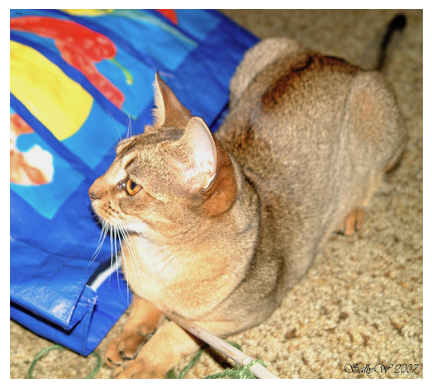

In [8]:
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array, array_to_img

plt.axis("off")
plt.imshow(load_img(input_img_paths[9]))

이제 대상 마스크도 살펴보겠습니다(그림 11.4 참조).

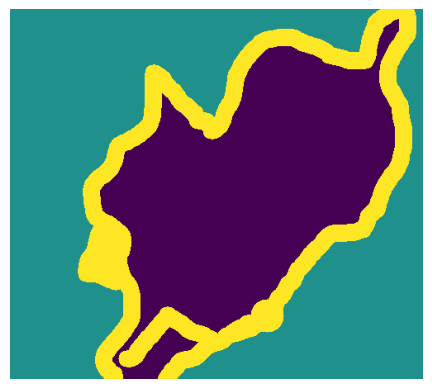

In [9]:
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

img = img_to_array(load_img(target_paths[9], color_mode="grayscale"))
display_target(img)

다음으로 입력값과 목표값을 두 개의 NumPy 배열에 로드해 보겠습니다. 데이터셋 크기가 매우 작으므로 모든 것을 메모리에 로드할 수 있습니다.

In [10]:
import numpy as np
import random

img_size = (200, 200)
num_imgs = len(input_img_paths)

random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale")
    )
    img = img.astype("uint8") - 1
    return img

input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

늘 그렇듯이, 배열을 학습 세트와 검증 세트로 나누겠습니다.

In [11]:
num_val_samples = 1000
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

#### Building and training the segmentation model

이제 우리의 모델을 정의할 차례입니다.

In [12]:
import keras
from keras.layers import Rescaling, Conv2D, Conv2DTranspose

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))
    x = Rescaling(1.0 / 255)(inputs)

    x = Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(64, 3, activation="relu", padding="same")(x)
    x = Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2D(128, 3, activation="relu", padding="same")(x)
    x = Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
    x = Conv2D(256, 3, activation="relu", padding="same")(x)

    x = Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)

    outputs = Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    return keras.Model(inputs, outputs)

model = get_model(img_size=img_size, num_classes=3)

**모델의 전반부**는 이미지 분류에 사용하는 컨볼루션 신경망(ConvNet)과 매우 유사합니다. **필터 크기가 점진적으로 증가하는 Conv2D 레이어들이 쌓여 있는 구조**입니다. 이미지를 2배씩 세 번 다운샘플링하여 **최종적으로 (25, 25, 256) 크기의 활성화 값**을 얻습니다. 이 전반부의 **목적은 이미지를 더 작은 특징 맵으로 인코딩**하는 것입니다. 각 공간 위치(또는 "픽셀")는 원본 이미지의 큰 공간 영역에 대한 정보를 담고 있습니다. **일종의 압축**이라고 생각하면 됩니다.

이 모델의 전반부와 이전에 살펴본 분류 모델의 중요한 차이점 중 하나는 다운샘플링 방식입니다. 8장의 분류 컨볼루션 신경망에서는 MaxPooling2D 레이어를 사용하여 특징 맵을 다운샘플링했습니다. **여기서는 컨볼루션 레이어마다 스트라이드를 추가하여 다운샘플링**합니다(컨볼루션 스트라이드의 작동 방식에 대한 자세한 내용은 8장 8.1.1절을 참조하세요). **이미지 분할의 경우, 모델의 출력으로 픽셀 단위의 목표 마스크를 생성해야 하므로 이미지 정보의 공간적 위치가 매우 중요**합니다. 2×2 맥스 풀링을 사용하면 각 풀링 윈도우 내의 위치 정보가 완전히 손실됩니다. 윈도우당 하나의 스칼라 값만 반환되는데, 이 값이 윈도우 내 네 위치 중 어디에서 왔는지에 대한 정보는 전혀 알 수 없습니다.

따라서 맥스 풀링 레이어는 분류 작업에서는 좋은 성능을 보이지만, 분할 작업에서는 오히려 성능 저하를 초래합니다. 반면, **스트라이드 컨볼루션은 위치 정보를 유지하면서 특징 맵을 더 효율적으로 다운샘플링**합니다. 이 책 전체에서, 17장의 생성 모델처럼 특징 위치 정보가 중요한 모델에서는 맥스 풀링 대신 스트라이드를 사용하는 경향이 있음을 알 수 있습니다.

**모델의 후반부는 Conv2DTranspose 레이어들의 스택으로 구성**됩니다. 이것들은 무엇일까요? 모델의 전반부 출력은 (25, 25, 256) 형태의 특징 맵이지만, 최종 출력은 원래 공간 차원과 일치하도록 각 픽셀에 대한 클래스를 예측해야 합니다. **최종 모델 출력은 (200, 200, num_classes) 형태가 되며, 여기서는 (200, 200, 3)**입니다. 따라서 지금까지 적용한 변환의 역변환, 즉 **특징 맵을 다운샘플링하는 대신 업샘플링하는 변환이 필요**합니다. 이것이 바로 Conv2DTranspose 레이어의 목적입니다. 이 레이어는 업샘플링을 학습하는 일종의 컨볼루션 레이어라고 생각할 수 있습니다. 

* 입력이 (100, 100, 64) 형태이고 이를 Conv2D(128, 3, strides=2, padding="same") 레이어를 통과시키면 출력은 (50, 50, 128)이 됩니다.
* 이 출력을 Conv2DTranspose(64, 3, strides=2, padding="same") 레이어를 통해 실행하면 원래와 동일한 (100, 100, 64) 형태의 출력이 반환됩니다.

따라서 입력을 Conv2D 레이어 스택을 통해 (25, 25, 256) 형태의 특징 맵으로 압축한 후, 해당 Conv2DTranspose 레이어 시퀀스와 마지막 Conv2D 레이어를 적용하면 (200, 200, 3) 형태의 출력을 생성할 수 있습니다.

**모델을 평가하기 위해 IoU(Intersection over Union)라는 지표**를 사용하겠습니다. **IoU는 실제 분할 마스크와 예측 마스크 간의 일치도를 나타내는 척도**입니다. 각 클래스별로 계산하거나 여러 클래스에 대한 평균을 낼 수 있습니다. 계산 과정은 다음과 같습니다.

1. 먼저 예측 마스크와 실제 마스크가 겹치는 영역인 교집합을 계산합니다.

2. 두 마스크가 모두 포함하는 전체 영역인 합집합을 계산합니다. 이는 목표 객체와 모델이 실수로 포함했을 수 있는 추가 영역을 모두 포함하는 전체 영역입니다.

3. 교집합 영역을 합집합 영역으로 나누어 IoU를 구합니다. **IoU는 0에서 1 사이의 값으로, 1은 완벽한 일치를, 0은 완전한 불일치**를 나타냅니다.

이 지표를 직접 구현하는 대신 Keras에 내장된 기능을 사용할 수도 있습니다.

In [13]:
# ⚠️NOTE⚠️: The following IoU metric is *very* slow on the PyTorch backend!
# If you are running with PyTorch, we recommend re-running the notebook with Jax
# or TensorFlow, or skipping to the next section of this chapter.

In [14]:
foreground_iou = keras.metrics.IoU(
    num_classes=3,
    target_class_ids=(0,),
    name="foreground_iou",
    sparse_y_true=True,
    sparse_y_pred=False,
)

이제 모델을 컴파일하고 적합시킬 수 있습니다.

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[foreground_iou],
)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "oxford_segmentation.keras",
        save_best_only=True,
    ),
]
history = model.fit(
    train_input_imgs,
    train_targets,
    epochs=50,
    callbacks=callbacks,
    batch_size=64,
    validation_data=(val_input_imgs, val_targets),
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - foreground_iou: 0.1005 - loss: 0.8988 - val_foreground_iou: 0.1131 - val_loss: 0.8123
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - foreground_iou: 0.4558 - loss: 0.7372 - val_foreground_iou: 0.4883 - val_loss: 0.6845
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - foreground_iou: 0.5106 - loss: 0.6369 - val_foreground_iou: 0.5584 - val_loss: 0.6075
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - foreground_iou: 0.5670 - loss: 0.5651 - val_foreground_iou: 0.5631 - val_loss: 0.5933
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - foreground_iou: 0.6002 - loss: 0.5223 - val_foreground_iou: 0.6408 - val_loss: 0.5073
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - foreground_iou: 0.6328 - loss: 0.4827 - val_foreground_iou: 0.6599 - val_loss: 0.4641
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - foreground_iou: 0.6652 - loss: 0.4428 - val_foreground_iou: 0.6751 - val_loss: 0.4599
Epoch 8/50
10

훈련 손실과 검증 손실을 표시해 보겠습니다(그림 11.5 참조).

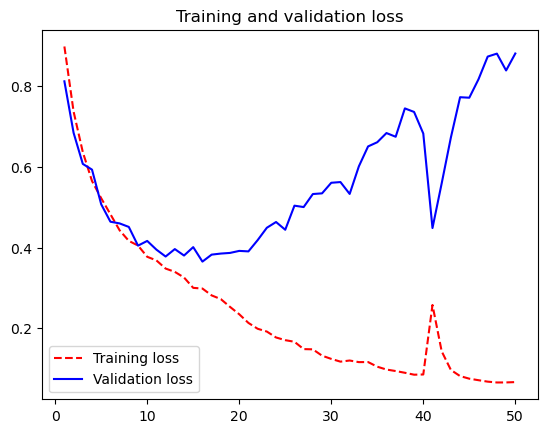

In [16]:
epochs = range(1, len(history.history["loss"]) + 1)
loss = history.history["loss"]
val_loss = history.history["val_loss"]
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()

보시다시피, 25번째 에포크쯤에서 과적합이 시작됩니다. 검증 손실에 따라 가장 성능이 좋은 모델을 다시 로드하고 이를 사용하여 분할 마스크를 예측하는 방법을 보여드리겠습니다(그림 11.6 참조).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


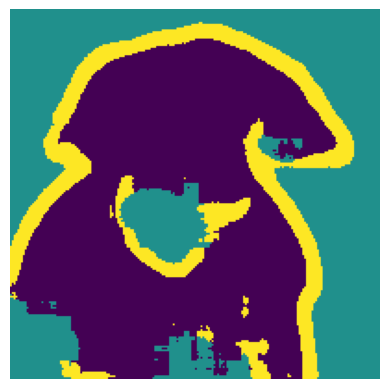

In [17]:
model = keras.models.load_model("oxford_segmentation.keras")

i = 4
test_image = val_input_imgs[i]
plt.axis("off")
plt.imshow(array_to_img(test_image))

mask = model.predict(np.expand_dims(test_image, 0))[0]

def display_mask(pred):
    mask = np.argmax(pred, axis=-1)
    mask *= 127
    plt.axis("off")
    plt.imshow(mask)

display_mask(mask)

전경과 배경의 기하학적 도형으로 인해 예측된 마스크에 몇 가지 작은 오류가 발생했습니다. 그럼에도 불구하고 저희 모델은 잘 작동하는 것으로 보입니다.

### Using a pretrained segmentation model

8장의 이미지 분류 예제에서 보셨듯이, 사전 학습된 모델을 사용하면 정확도를 크게 향상시킬 수 있습니다. 특히 학습에 사용할 샘플이 적을 때 더욱 그렇습니다. 이미지 분할도 마찬가지입니다.

Segment Anything Model(SAM)[1]은 거의 모든 작업에 사용할 수 있는 강력한 사전 학습된 분할 모델입니다. Meta AI에서 개발하여 2023년 4월에 출시된 이 모델은 1,100만 장의 이미지와 해당 분할 마스크를 사용하여 학습되었으며, 10억 개 이상의 객체 인스턴스를 포함합니다. 이처럼 방대한 학습 데이터 덕분에 모델은 자연 이미지에 나타나는 거의 모든 객체에 대한 지식을 내장하고 있습니다.

SAM의 가장 큰 혁신은 미리 정의된 객체 클래스에 국한되지 않는다는 점입니다. 찾고자 하는 객체의 예시만 제공하면 새로운 객체도 분할할 수 있습니다. 모델을 먼저 미세 조정할 필요조차 없습니다. 이제 어떻게 작동하는지 살펴보겠습니다.

#### Downloading the Segment Anything Model

먼저 SAM 인스턴스를 생성하고 가중치를 다운로드해 보겠습니다. KerasHub 패키지를 사용하면 처음부터 직접 구현할 필요 없이 사전 학습된 모델을 바로 사용할 수 있습니다.

이전 장에서 사용했던 ImageClassifier 태스크를 기억하시나요? KerasHub의 ImageSegmenter 태스크를 사용하면 사전 학습된 이미지 분할 모델을 표준 입력과 출력을 가진 고수준 모델로 래핑할 수 있습니다. 여기서는 sam_huge_sa1b 사전 학습 모델을 사용하겠습니다. sam은 모델, huge는 모델의 파라미터 개수, sa1b는 모델과 함께 공개된 SA-1B 데이터셋(10억 개의 마스크 주석 포함)을 의미합니다. 지금 바로 다운로드해 보겠습니다.

In [18]:
import keras_hub

model = keras_hub.models.ImageSegmenter.from_preset("sam_huge_sa1b")

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 3.06k/3.06k [00:00<00:00, 3.73MB/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 5.77k/5.77k [00:00<00:00, 1.70MB/s]


TypeError: <class 'keras_hub.src.models.sam.sam_image_segmenter.SAMImageSegmenter'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras_hub.src.models.sam.sam_image_segmenter', 'class_name': 'SAMImageSegmenter', 'config': {'backbone': <SAMBackbone name=sam_backbone, built=True>, 'preprocessor': {'module': 'keras_hub.src.models.sam.sam_image_segmenter_preprocessor', 'class_name': 'SAMImageSegmenterPreprocessor', 'config': {'name': 'sam_image_segmenter_preprocessor', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'image_converter': {'module': 'keras_hub.src.models.sam.sam_image_converter', 'class_name': 'SAMImageConverter', 'config': {'name': 'sam_image_converter', 'trainable': True, 'dtype': {'module': 'keras', 'cl

우선 가장 먼저 눈에 띄는 것은 우리 모델의 규모가 상당히 크다는 점입니다.

In [19]:
model.count_params()

2880643

6억 4천 1백만 개의 파라미터를 가진 SAM은 이 책에서 지금까지 사용한 모델 중 가장 큰 모델입니다. 사전 학습된 모델이 점점 더 커지고 더 많은 데이터를 사용하는 추세는 16장에서 더 자세히 다룰 것입니다.

#### How Segment Anything works

모델을 사용하여 분할 작업을 수행하기 전에 SAM이 어떻게 작동하는지 좀 더 자세히 살펴보겠습니다. 모델의 성능은 방대한 사전 학습 데이터셋에서 비롯됩니다. Meta는 SA-1B 데이터셋을 모델과 함께 개발했으며, 부분적으로 학습된 모델은 데이터 레이블링 프로세스를 지원하는 데 사용되었습니다. 즉, 데이터셋과 모델은 일종의 피드백 루프를 통해 함께 개발되었습니다.

SA-1B 데이터셋의 목표는 이미지의 모든 객체에 고유한 분할 마스크가 부여된 완전히 분할된 이미지를 생성하는 것입니다. 그림 11.7을 참조하십시오. 데이터셋의 각 이미지에는 평균적으로 약 100개의 마스크가 있으며, 일부 이미지에는 500개 이상의 개별 마스크가 적용된 객체가 있습니다. 이는 점진적으로 자동화되는 데이터 수집 파이프라인을 통해 이루어졌습니다. 처음에는 전문가들이 소규모 예제 데이터셋의 이미지를 수동으로 분할하여 초기 모델을 학습시켰습니다. 이 모델은 반자동 데이터 수집 단계를 진행하는 데 사용되었습니다. 이 단계에서는 SAM을 사용하여 이미지를 먼저 분할한 후, 전문가의 수정 및 추가 주석 작업을 통해 이미지를 개선했습니다.

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch11/sa1b_example.6701768b.jpg" width="600"><br">Figure 11.7: An example image from the SA-1B dataset</p>

이 모델은 (이미지, 프롬프트, 마스크) 트리플을 사용하여 학습됩니다. 이미지와 프롬프트는 모델의 입력입니다. 이미지는 어떤 이미지든 될 수 있으며, 프롬프트는 다음과 같은 형태를 취할 수 있습니다.

* 마스크를 적용할 객체 내부의 점
* 마스크를 적용할 객체 주변의 사각형

이미지와 프롬프트 입력이 주어지면, 모델은 프롬프트가 가리키는 객체에 대해 정확한 예측 마스크를 생성하고, 이를 정답 마스크 레이블과 비교합니다.

모델은 몇 가지 구성 요소로 이루어져 있습니다. 이전 장에서 사용했던 Xception 모델과 유사한 이미지 인코더는 입력 이미지를 받아 훨씬 작은 이미지 임베딩을 출력합니다. 이는 이미 구현 방법을 알고 있는 부분입니다.

다음으로, 프롬프트 인코더는 앞서 언급한 모든 형태의 프롬프트를 임베딩 벡터로 매핑하는 역할을 하며, 마스크 디코더는 이미지 임베딩과 프롬프트 임베딩을 입력으로 받아 몇 가지 가능한 예측 마스크를 출력합니다. 프롬프트 인코더와 마스크 디코더는 이후 장에서 다룰 모델링 기법을 사용하기 때문에 여기서는 자세히 설명하지 않겠습니다. 이 장의 앞부분에서 했던 것처럼 예측된 마스크를 실제 마스크와 비교할 수 있습니다(그림 11.8 참조).

<p style="text-align:center">
<img src="https://deeplearningwithpython.io/images/ch11/sam_architecture.dad9dae6.png" width="600"><br>Figure 11.8: The Segment Anything high-level architecture overview</p>

이러한 모든 하위 구성 요소는 SA-1B 이미지 및 마스크 데이터로부터 학습에 사용할 새로운 (이미지, 프롬프트, 마스크) 트리플 배치를 생성하여 동시에 학습됩니다. 이 과정은 실제로 매우 간단합니다. 주어진 입력 이미지에 대해 입력에서 임의의 마스크를 선택합니다. 다음으로, 상자 프롬프트 또는 점 프롬프트 중 어떤 것을 생성할지 무작위로 선택합니다. 점 프롬프트를 생성하려면 마스크 레이블 내부의 임의의 픽셀을 선택합니다. 상자 프롬프트를 생성하려면 마스크 레이블 내부의 모든 점을 둘러싸는 상자를 그립니다. 이 과정을 무한히 반복하여 각 이미지 입력에서 여러 개의 (이미지, 프롬프트, 마스크) 트리플을 샘플링할 수 있습니다.

#### Preparing a test image

모델을 실제로 사용해 보면서 좀 더 구체적으로 살펴보겠습니다. 먼저 분할 작업을 위한 테스트 이미지를 불러오겠습니다. 과일이 담긴 그릇 사진을 사용하겠습니다(그림 11.9 참조).

259153/259153 ━━━━━━━━━━━━━━━━━━━━ 1s 4us/step


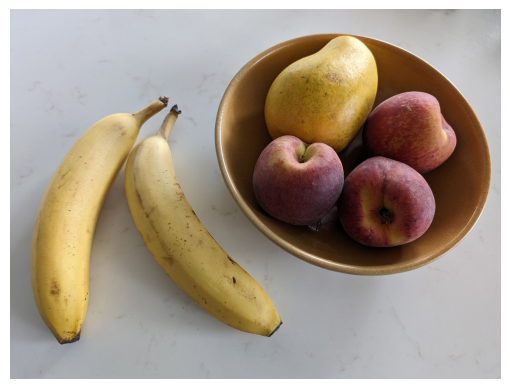

In [20]:
path = keras.utils.get_file(
    origin="https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"
)
pil_image = keras.utils.load_img(path)
image_array = keras.utils.img_to_array(pil_image)

plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.show()

SAM은 1024 × 1024 크기의 입력을 기대합니다. 하지만 임의의 이미지를 1024 × 1024로 강제로 크기 조정하면 종횡비가 왜곡됩니다. 예를 들어, 우리의 이미지는 정사각형이 아닙니다. 따라서 먼저 이미지의 가장 긴 변의 길이가 1024픽셀이 되도록 크기를 조정한 다음 나머지 픽셀을 0과 같은 채움 값으로 채우는 것이 좋습니다. keras.ops.image.resize() 연산에서 pad_to_aspect_ratio 인수를 사용하면 다음과 같이 구현할 수 있습니다.

In [21]:
from keras import ops

image_size = (1024, 1024)

def resize_and_pad(x):
    return ops.image.resize(x, image_size, pad_to_aspect_ratio=True)

image = resize_and_pad(image_array)

다음으로, 모델을 사용할 때 유용하게 쓰일 몇 가지 유틸리티를 정의해 보겠습니다. 다음과 같은 기능이 필요합니다.

* 이미지 표시
* 이미지 위에 분할 마스크 표시
* 이미지의 특정 지점 강조 표시
* 이미지 위에 상자 표시

모든 유틸리티는 Matplotlib의 축 객체(ax로 표기)를 매개변수로 받아 동일한 그림에 출력할 수 있도록 합니다.

In [22]:
import matplotlib.pyplot as plt
from keras import ops

def show_image(image, ax):
    ax.imshow(ops.convert_to_numpy(image).astype("uint8"))

def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w, _ = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x, y, c="green", marker="*", s=375, ec="white", lw=1.25)

def show_box(box, ax):
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec="red", fc="none", lw=2))

#### Prompting the model with a target point

SAM을 사용하려면 프롬프트를 제공해야 합니다. 즉, 다음 중 하나가 필요합니다.

점 프롬프트 - 이미지에서 점을 선택하고 모델이 해당 점이 속한 객체를 분할하도록 합니다.
상자 프롬프트 - 객체 주위에 대략적인 상자를 그립니다(정확할 필요는 없습니다). 모델이 상자 안의 객체를 분할하도록 합니다.

먼저 점 프롬프트부터 살펴보겠습니다. 점에는 레이블이 지정되어 있으며, 1은 전경(분할하려는 객체)을, 0은 배경(객체 주변의 모든 것)을 나타냅니다. 모호한 경우, 결과를 개선하기 위해 단일 점 대신 여러 개의 레이블이 지정된 점을 전달하여 포함할 영역(레이블 1)과 제외할 영역(레이블 0)을 더욱 세밀하게 정의할 수 있습니다.

전경 점 하나를 사용해 보겠습니다(그림 11.10 참조). 다음은 테스트 점입니다.

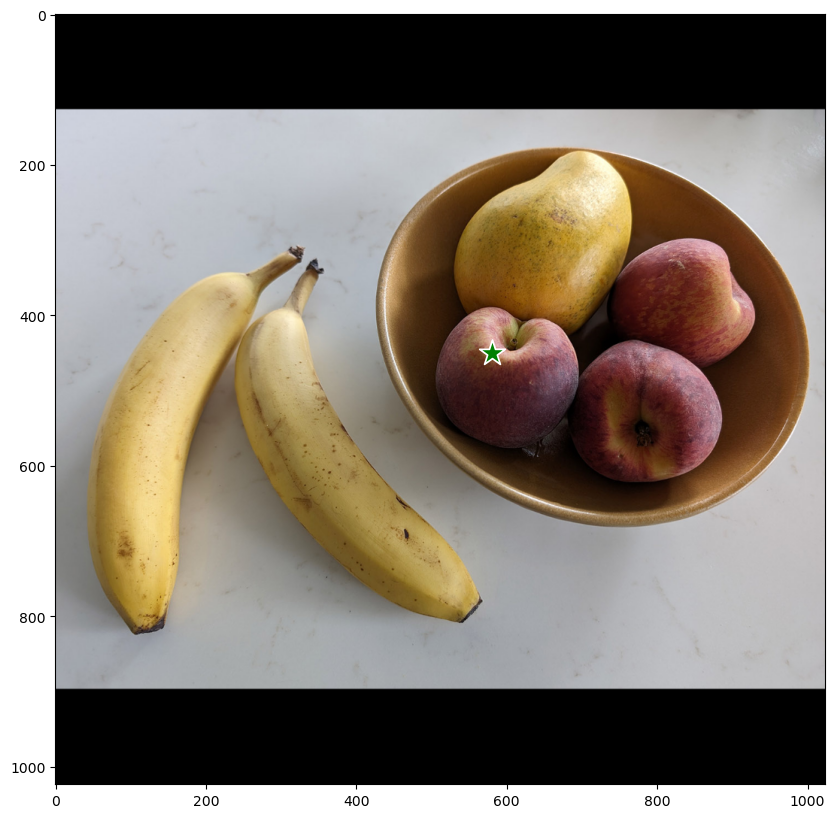

In [23]:
import numpy as np

input_point = np.array([[580, 450]])
input_label = np.array([1])

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_points(input_point, plt.gca())
plt.show()

샘에게 이 내용을 알려줍시다.

In [ ]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0),
    }
)

반환 값 출력에는 대상 객체에 대한 256 × 256 크기의 후보 마스크 4개가 포함된 "masks" 필드가 있으며, 이 마스크들은 일치 품질이 높은 순서대로 정렬되어 있습니다. 마스크의 품질 점수는 모델 출력의 "iou_pred" 필드에서 확인할 수 있습니다.

In [ ]:
outputs["masks"].shape

첫 번째 마스크를 이미지 위에 겹쳐 보겠습니다(그림 11.11 참조).

In [ ]:
def get_mask(sam_outputs, index=0):
    mask = sam_outputs["masks"][0][index]
    mask = np.expand_dims(mask, axis=-1)
    mask = resize_and_pad(mask)
    return ops.convert_to_numpy(mask) > 0.0

mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

꽤 괜찮네요!

다음으로 바나나를 시도해 보겠습니다. 모델에 좌표 (300, 550)을 입력하면 왼쪽에서 두 번째 바나나가 표시됩니다(그림 11.12 참조).

In [ ]:
input_point = np.array([[300, 550]])
input_label = np.array([1])

outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "points": ops.expand_dims(input_point, axis=0),
        "labels": ops.expand_dims(input_label, axis=0),
    }
)
mask = get_mask(outputs, index=0)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.show()

그렇다면 나머지 마스크 후보들은 어떨까요? 이러한 마스크들은 모호한 질문에 유용하게 사용될 수 있습니다. 나머지 세 가지 마스크를 그래프로 나타내 보겠습니다(그림 11.13 참조).

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 60))
masks = outputs["masks"][0][1:]
for i, mask in enumerate(masks):
    show_image(image, axes[i])
    show_points(input_point, axes[i])
    mask = get_mask(outputs, index=i + 1)
    show_mask(mask, axes[i])
    axes[i].set_title(f"Mask {i + 1}", fontsize=16)
    axes[i].axis("off")
plt.show()

보시는 바와 같이, 모델이 찾아낸 또 다른 분할 방식에는 바나나가 모두 포함됩니다.

#### Prompting the model with a target box

하나 이상의 목표 지점을 제공하는 것 외에도, 분할할 객체의 위치를 ​​근사적으로 나타내는 상자를 제공할 수 있습니다. 이러한 상자는 왼쪽 상단 모서리와 오른쪽 하단 모서리의 좌표를 통해 전달되어야 합니다. 다음은 망고를 둘러싼 상자의 예입니다(그림 11.14 참조).

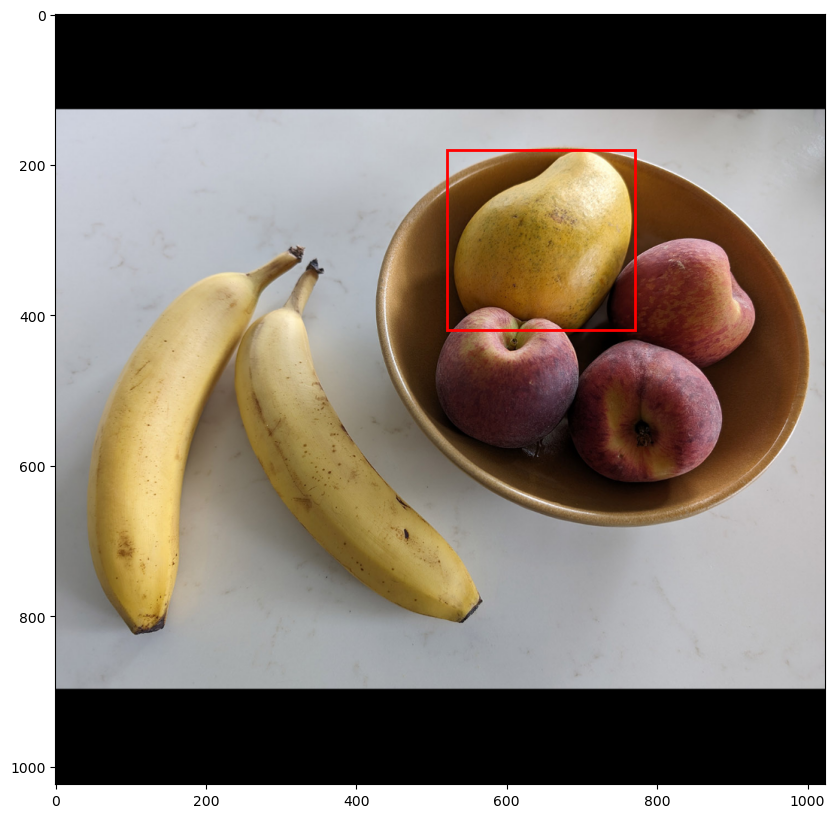

In [29]:
input_box = np.array(
    [
        [520, 180],
        [770, 420],
    ]
)

plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_box(input_box, plt.gca())
plt.show()

이를 SAM에 입력해 보겠습니다(그림 11.15 참조).

In [ ]:
outputs = model.predict(
    {
        "images": ops.expand_dims(image, axis=0),
        "boxes": ops.expand_dims(input_box, axis=(0, 1)),
    }
)
mask = get_mask(outputs, 0)
plt.figure(figsize=(10, 10))
show_image(image, plt.gca())
show_mask(mask, plt.gca())
show_box(input_box, plt.gca())
plt.show()

SAM은 분할 마스크로 주석이 달린 대규모 이미지 데이터셋을 빠르게 생성하는 강력한 도구입니다.

### 요약

* 이미지 분할은 컴퓨터 비전 작업의 주요 범주 중 하나입니다. 이미지의 내용을 픽셀 수준에서 설명하는 분할 마스크를 계산하는 작업입니다.
* 자체 분할 모델을 구축하려면, 스트라이드 Conv2D 레이어를 여러 개 사용하여 입력 이미지를 더 작은 특징 맵으로 "압축"한 다음, 이에 상응하는 Conv2DTranspose 레이어를 여러 개 사용하여 특징 맵을 입력 이미지와 동일한 크기의 분할 마스크로 "확장"합니다.
* 사전 학습된 분할 모델을 사용할 수도 있습니다. KerasHub에 포함된 Segment Anything은 이미지 입력, 텍스트 입력, 점 입력, 상자 입력 등을 지원하는 강력한 모델입니다.